In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import scipy as stats #para la parte estadistica
from scipy import stats

In [2]:
df = pd.read_csv('/content/healthcare_dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

### 1. Duplicates Check

In [4]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 534


### 2. Removing Duplicates

In [5]:
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {len(df)}")

Number of rows after removing duplicates: 54966


### 3. Categorical and Numerical Variables Identification

In [6]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", categorical_cols.tolist())
print("Numerical Columns:", numerical_cols.tolist())

Categorical Columns: ['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']
Numerical Columns: ['Age', 'Billing Amount', 'Room Number']


### 4. Missing Values Check

As observed from `df.info()`, there are no missing values in the dataset, so no imputation is needed.

In [7]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


### 5. Cardinality of Categorical Variables

To check the cardinality of categorical variables, we can count the number of unique values in each column.

In [8]:
print('Cardinality of Categorical Columns:')
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Cardinality of Categorical Columns:
Name: 49992 unique values
Gender: 2 unique values
Blood Type: 8 unique values
Medical Condition: 6 unique values
Date of Admission: 1827 unique values
Doctor: 40341 unique values
Hospital: 39876 unique values
Insurance Provider: 5 unique values
Admission Type: 3 unique values
Discharge Date: 1856 unique values
Medication: 5 unique values
Test Results: 3 unique values


### 6. Date Conversion and Correction

As observed, 'Date of Admission' and 'Discharge Date' are currently `object` (string) types. Converting them to `datetime` objects is essential for any time-series analysis or calculations involving dates (e.g., duration of stay). I will use `pd.to_datetime` for this conversion.

In [9]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

print('Data types after date conversion:')
display(df[['Date of Admission', 'Discharge Date']].info())

Data types after date conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date of Admission  54966 non-null  datetime64[ns]
 1   Discharge Date     54966 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 1.3 MB


None

### 7. Exploratory Data Analysis (EDA) - Categorical Variables

To make the categorical variable plots more informative and prevent issues with high cardinality, I will exclude columns like 'Name', 'Doctor', 'Hospital', 'Date of Admission', and 'Discharge Date' from the count plots. These columns typically have too many unique values to provide useful insights through bar charts and can cause performance issues.

/tmp/ipykernel_2786/1929134787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


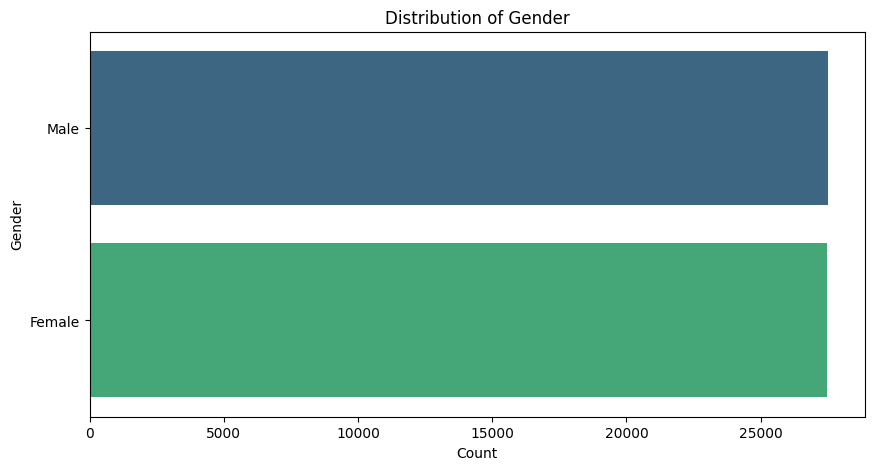

/tmp/ipykernel_2786/1929134787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


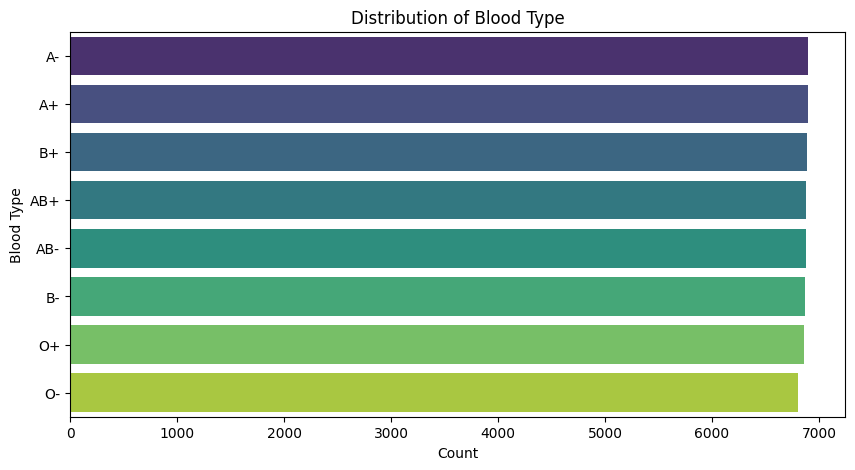

/tmp/ipykernel_2786/1929134787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


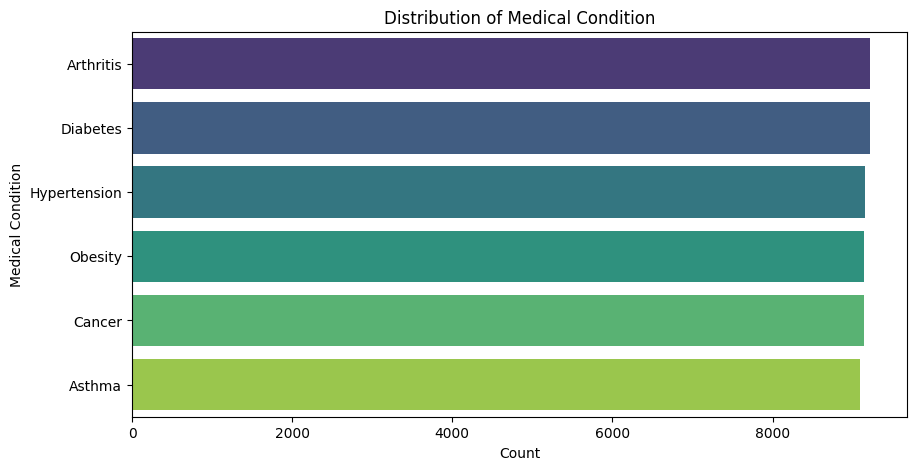

/tmp/ipykernel_2786/1929134787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


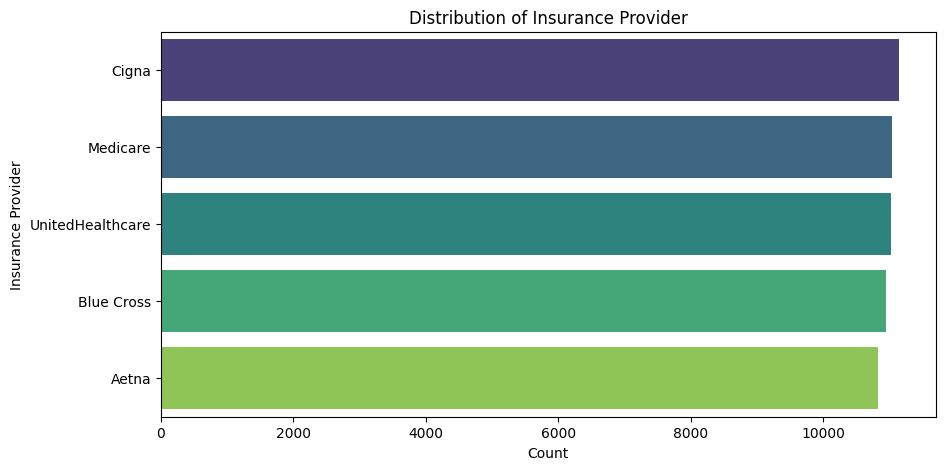

/tmp/ipykernel_2786/1929134787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


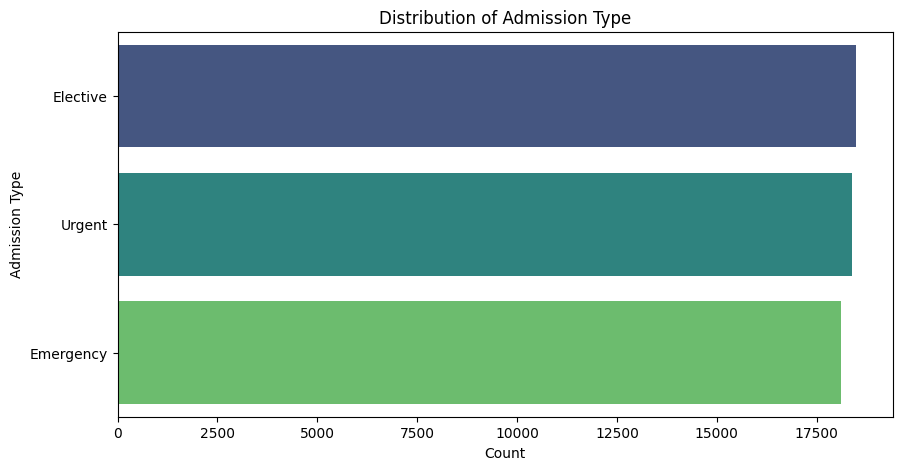

/tmp/ipykernel_2786/1929134787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


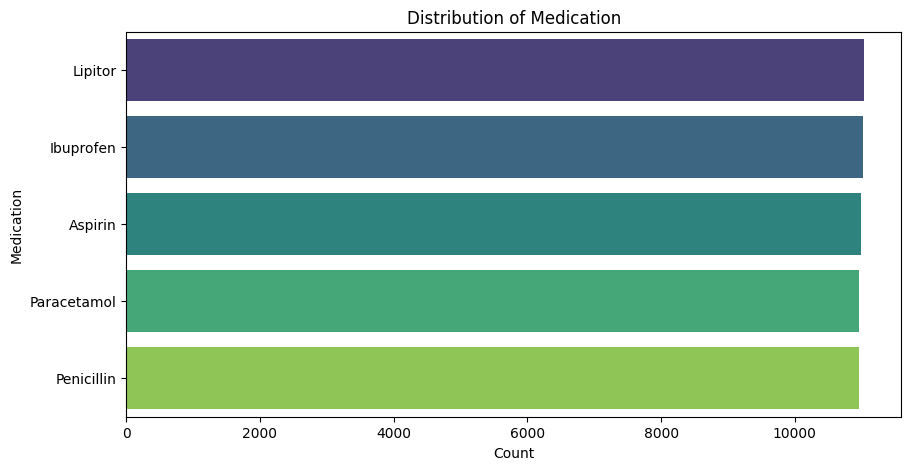

/tmp/ipykernel_2786/1929134787.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


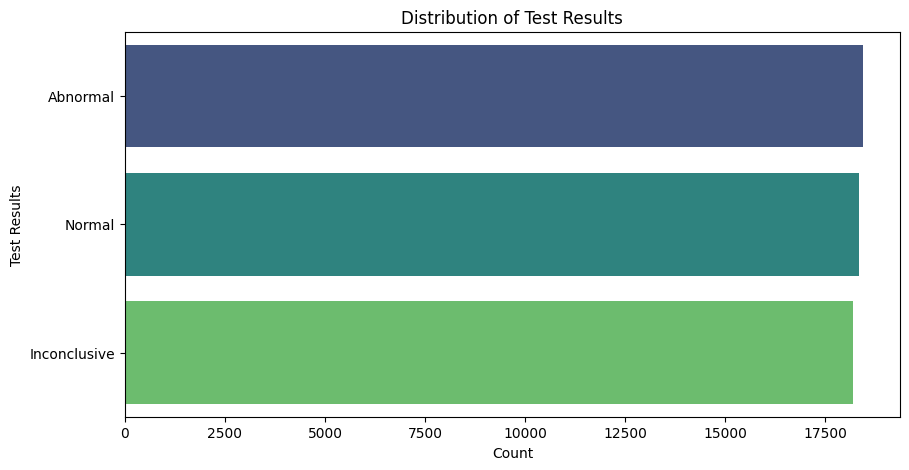

In [10]:
high_cardinality_cols = ['Name', 'Doctor', 'Hospital', 'Date of Admission', 'Discharge Date']
filtered_categorical_cols = [col for col in categorical_cols if col not in high_cardinality_cols]

for col in filtered_categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

### 8. Exploratory Data Analysis (EDA) - Numerical Variables and Outlier Detection

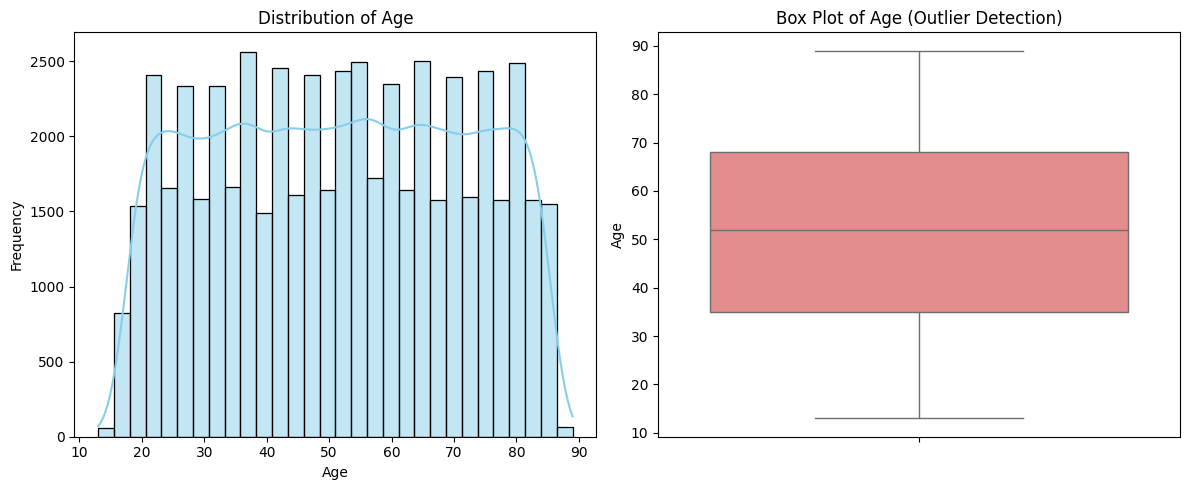

Number of outliers in Age: 0


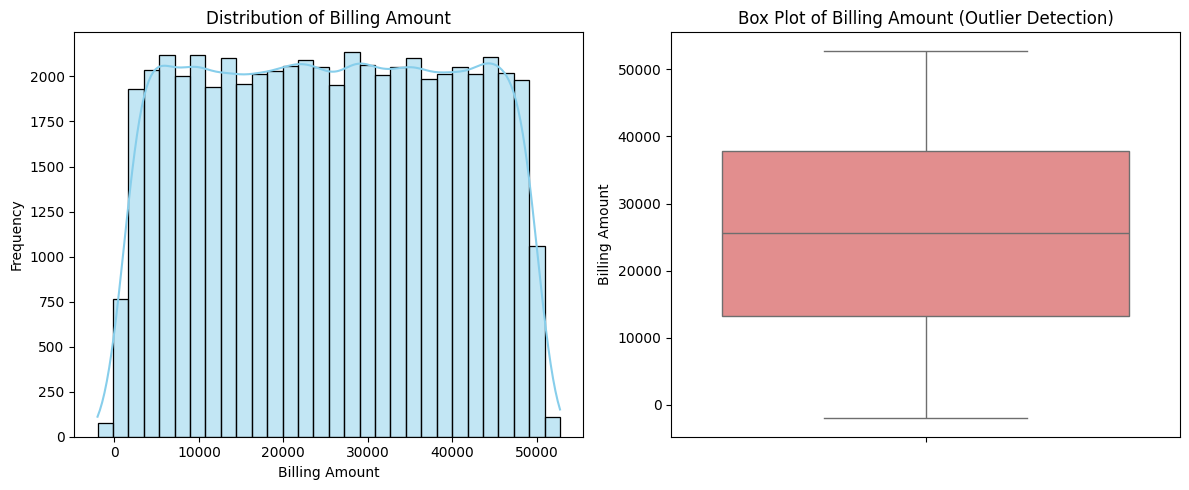

Number of outliers in Billing Amount: 0


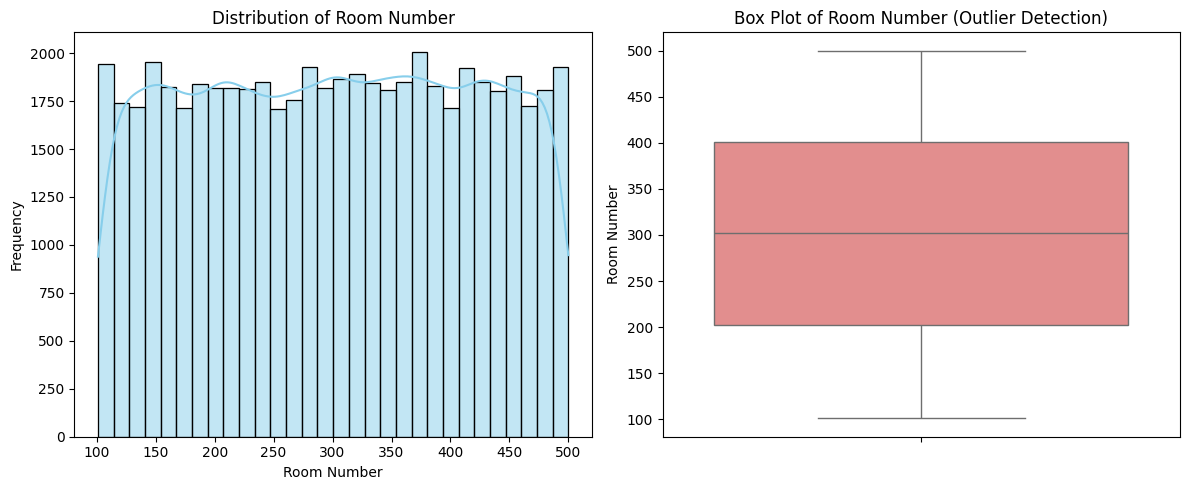

Number of outliers in Room Number: 0


In [11]:
for col in numerical_cols:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Box Plot of {col} (Outlier Detection)')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Number of outliers in {col}: {len(outliers)}")

### 9. creation of useful variables

In [16]:
# 1. Calculate 'Length of Stay' (in days)
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Ensure that the duration is not negative (which would imply a discharge date earlier than the admission date)
df['Length of Stay'] = df['Length of Stay'].apply(lambda x: x if x >= 0 else 0)

print(f"'Length of Stay' (days): Minimum = {df['Length of Stay'].min()}, Maximum = {df['Length of Stay'].max()}, Average = {df['Length of Stay'].mean():.2f}")


'Length of Stay' (days): Minimum = 1, Maximum = 30, Average = 15.50


In [17]:
# 2. Extract 'Admission Day of Week', 'Admission Month', and 'Admission Year'
df['Admission Day of Week'] = df['Date of Admission'].dt.day_name()
df['Admission Month'] = df['Date of Admission'].dt.month_name()
df['Admission Year'] = df['Date of Admission'].dt.year

print("Unique values for 'Admission Day of Week':", df['Admission Day of Week'].unique())
print("Unique values for 'Admission Month':", df['Admission Month'].unique())
print("Unique values for 'Admission Year':", df['Admission Year'].unique())


Unique values for 'Admission Day of Week': ['Wednesday' 'Tuesday' 'Thursday' 'Monday' 'Sunday' 'Friday' 'Saturday']
Unique values for 'Admission Month': ['January' 'August' 'September' 'November' 'December' 'July' 'May' 'April'
 'October' 'June' 'March' 'February']
Unique values for 'Admission Year': [2024 2019 2022 2020 2023 2021]


Verification of new columns

In [18]:
print('DataFrame Info with new columns:')
df.info()

print('\nFirst 5 rows with new columns:')
display(df[['Date of Admission', 'Discharge Date', 'Length of Stay', 'Admission Day of Week', 'Admission Month', 'Admission Year']].head())

DataFrame Info with new columns:
<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Name                   54966 non-null  object        
 1   Age                    54966 non-null  int64         
 2   Gender                 54966 non-null  object        
 3   Blood Type             54966 non-null  object        
 4   Medical Condition      54966 non-null  object        
 5   Date of Admission      54966 non-null  datetime64[ns]
 6   Doctor                 54966 non-null  object        
 7   Hospital               54966 non-null  object        
 8   Insurance Provider     54966 non-null  object        
 9   Billing Amount         54966 non-null  float64       
 10  Room Number            54966 non-null  float64       
 11  Admission Type         54966 non-null  object        
 12  Discharge Date         54966 non

,Date of Admission,Discharge Date,Length of Stay,Admission Day of Week,Admission Month,Admission Year
0,2024-01-31,2024-02-02,2,Wednesday,January,2024
1,2019-08-20,2019-08-26,6,Tuesday,August,2019
2,2022-09-22,2022-10-07,15,Thursday,September,2022
3,2020-11-18,2020-12-18,30,Wednesday,November,2020
4,2022-09-19,2022-10-09,20,Monday,September,2022


In [20]:
# export processed dataset
df.to_csv('healthcare_processed.csv', index=False)

print("Dataset procesado exportado exitosamente a 'healthcare_processed.csv'")

Dataset procesado exportado exitosamente a 'healthcare_processed.csv'
